In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and prepare data

In [2]:
data = pd.read_csv('sdss_star_galaxy.csv')

In [3]:
feature_columns = ['u_g', 'g_r', 'r_i', 'petro_radius']

In [4]:
X = data[['u_g', 'g_r', 'r_i', 'petro_radius']]
y = data['is_galaxy'] #galaxy = 1; star = 0

# 2. Split data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train logistic regression

In [6]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# 4. Predictions

In [7]:
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
#y_pred_prob = log_reg.predict_proba(X_test)[:, :]

In [8]:
print('Prediction examples')
for j in range(len(y_pred)):
    print(f'{list(X_test.u_g)[j]:+13.9f} {list(X_test.g_r)[j]:+13.9f}',\
          f'{list(X_test.r_i)[j]:+13.9f} {list(X_test.petro_radius)[j]:+13.9f}',\
          f'{y_pred_proba[j]:+13.9f} {y_pred[j]:1d}')

Prediction examples
 +0.991643313  +1.234338926  +0.621246312  +1.391705650  +0.995735714 1
 +0.952018441  +0.451831032  -0.036595571  +0.006490682  +0.015569168 0
 +1.731344517  +0.669153368  +0.429551181  +0.023426465  +0.918574174 1
 +1.013930964  +0.389543385  +0.175057917  +0.108899330  +0.052284013 0
 +0.796271570  +1.111147670  +0.220914408  +1.691911642  +0.893269912 1
 +1.939633919  +1.114073538  +0.544489397  +2.816566898  +0.999902853 1
 +1.073140214  +0.517157265  -0.063948416  +0.634198978  +0.054641585 0
 +1.351084967  +0.349138817  +0.467871163  +3.546859296  +0.973835672 1
 +1.406872009  +0.076066021  +0.041724134  +0.563232693  +0.031028728 0
 +1.411314258  +1.561814487  +0.146948318  +1.663987234  +0.997787218 1
 +0.748234743  +0.294889186  +0.052377913  +0.258093113  +0.007709566 0
 +2.116830512  +0.501923145  +0.709727859  +1.910140547  +0.998695482 1
 +2.462716055  +0.651040479  +0.364773299  +0.263802565  +0.991323420 1
 +1.054559877  +0.385763300  +0.209646923  +

# 5. Comprehensive evaluation

In [9]:
print('=== Logistic regression results ===')
print(f"Training accuracy: {log_reg.score(X_train, y_train):.3f}")
print(f"Test accuracy:     {log_reg.score(X_test, y_test):.3f}")
print(f"ROC AUC:           {roc_auc_score(y_test, y_pred_proba):.3f}")

=== Logistic regression results ===
Training accuracy: 0.964
Test accuracy:     0.972
ROC AUC:           0.996


# 6. Cross validation

In [10]:
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

Cross-validation accuracy: 0.964 (+/- 0.017)


# 7. Detailed classification report

In [11]:
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['Star', 'Galaxy']))


Classification report:
              precision    recall  f1-score   support

        Star       0.97      0.97      0.97       302
      Galaxy       0.97      0.97      0.97       298

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



# 8. Feature importance

In [13]:
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': log_reg.coef_[0],
    'abs_coefficient': np.abs(log_reg.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

In [14]:
print("\nFeature importance:")
print(feature_importance)


Feature importance:
        feature  coefficient  abs_coefficient
2           r_i     5.877308         5.877308
1           g_r     5.175407         5.175407
0           u_g     3.447292         3.447292
3  petro_radius     1.116970         1.116970


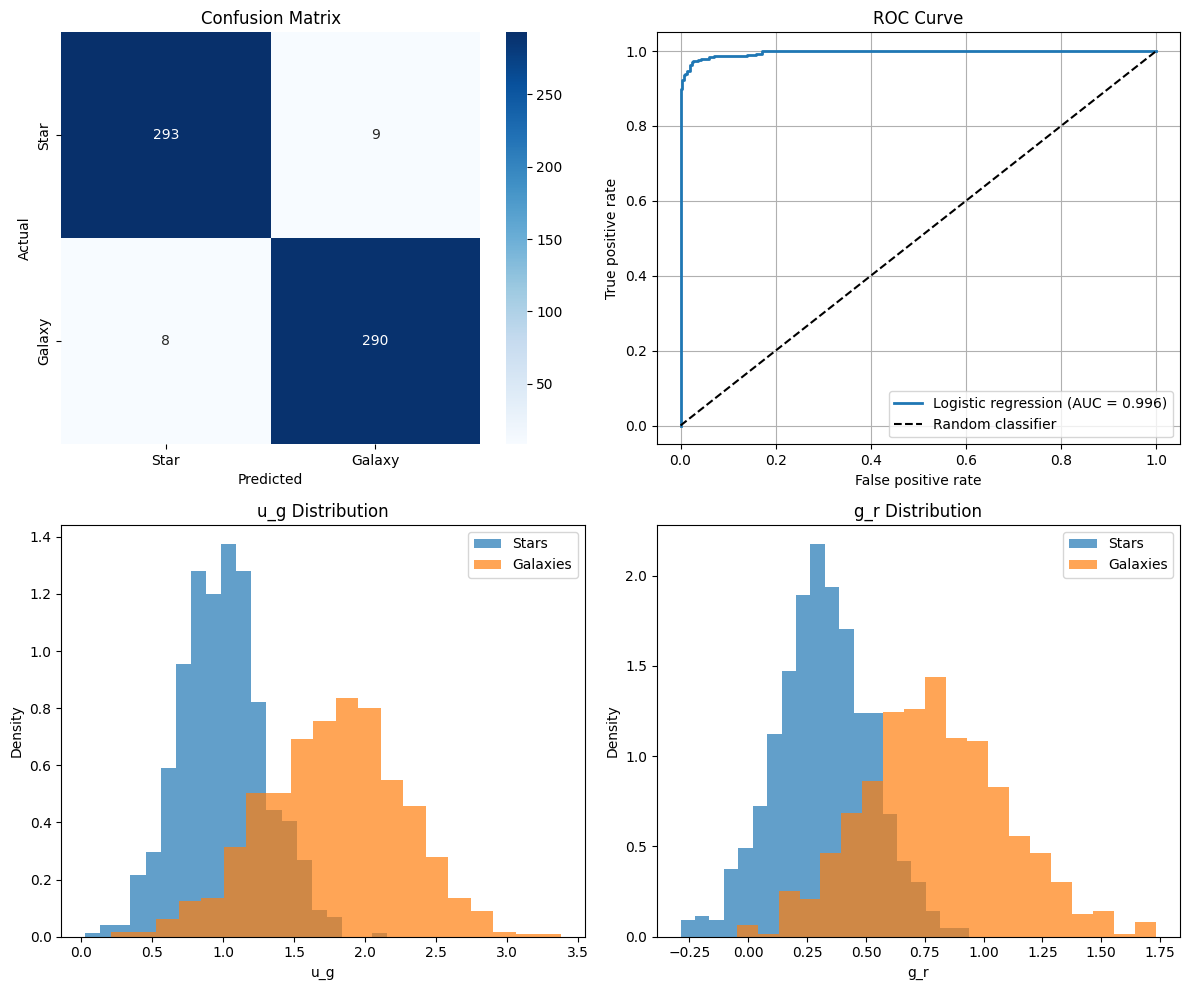

In [20]:
# Plotting results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Star', 'Galaxy'], yticklabels=['Star', 'Galaxy'], ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes [0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, threshholds = roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, linewidth=2, label=f'Logistic regression (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
axes [0, 1].plot([0, 1], [0, 1], 'k--', label='Random classifier')
axes[0, 1].set_xlabel('False positive rate')
axes[0, 1].set_ylabel('True positive rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes [0, 1].grid(True)

# Feature distributions by Class
for i, feature in enumerate(feature_columns[:2]):
    axes[1, i].hist(X_train[y_train == 0][feature], alpha=0.7, label='Stars', bins=20, density=True)
    axes[1, i].hist(X_train[y_train == 1][feature], alpha=0.7, label='Galaxies', bins=20, density=True)
    axes[1, i].set_xlabel(feature)
    axes[1, i].set_ylabel('Density')
    axes[1, i].legend()
    axes[1, i].set_title(f'{feature} Distribution')

plt.tight_layout()
plt.savefig('starGalaxyLogRegress.jpg')
plt.show()